In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import pandas as pd
import seaborn as sns

# Load the 'planets' dataset directly from seaborn
df = sns.load_dataset('planets')

print("Dataset loaded successfully!")
# Show the first 5 rows to make sure it worked
df.head()

Dataset loaded successfully!


,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


In [8]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check data types
print("\nData Types:")
print(df.dtypes)

Missing values per column:
method              0
number              0
orbital_period     43
mass              522
distance          227
year                0
dtype: int64

Data Types:
method                str
number              int64
orbital_period    float64
mass              float64
distance          float64
year                int64
dtype: object


In [9]:
# 1. Fill missing 'mass' with the median value
mass_median = df['mass'].median()
df['mass'] = df['mass'].fillna(mass_median)

# 2. Fill missing 'distance' with the median value
distance_median = df['distance'].median()
df['distance'] = df['distance'].fillna(distance_median)

# 3. For 'orbital_period', let's just drop the 43 rows since it's a small number
df.dropna(subset=['orbital_period'], inplace=True)

# Verify the fix
print("New Missing Values Count:")
print(df.isnull().sum())

New Missing Values Count:
method            0
number            0
orbital_period    0
mass              0
distance          0
year              0
dtype: int64


In [10]:
# Let's say we don't need 'number' for our analysis
df.drop(columns=['number'], inplace=True)
df.head()

,method,orbital_period,mass,distance,year
0,Radial Velocity,269.300,7.10,77.40,2006
1,Radial Velocity,874.774,2.21,56.95,2008
2,Radial Velocity,763.000,2.60,19.84,2011
3,Radial Velocity,326.030,19.40,110.62,2007
4,Radial Velocity,516.220,10.50,119.47,2009


In [11]:
# Make all methods lowercase and remove any accidental leading/trailing spaces
df['method'] = df['method'].str.lower().str.strip()

# Check the unique values to ensure they are clean
print("Unique Methods:")
print(df['method'].unique())

Unique Methods:
<StringArray>
[              'radial velocity',     'eclipse timing variations',
                       'imaging',                       'transit',
                    'astrometry',     'transit timing variations',
 'orbital brightness modulation',                  'microlensing',
                 'pulsar timing',   'pulsation timing variations']
Length: 10, dtype: str


In [12]:
# Create a function to categorize the years
def discovery_era(year):
    if year < 2000:
        return 'Pre-2000'
    elif 2000 <= year < 2010:
        return '2000-2010'
    else:
        return 'Post-2010'

# Apply the function to create a new column
df['era'] = df['year'].apply(discovery_era)

# Check the first few rows to see the new column
df[['method', 'year', 'era']].head()

,method,year,era
0,radial velocity,2006,2000-2010
1,radial velocity,2008,2000-2010
2,radial velocity,2011,Post-2010
3,radial velocity,2007,2000-2010
4,radial velocity,2009,2000-2010


In [13]:
# Group by method and find the average mass
method_mass = df.groupby('method')['mass'].mean().sort_values(ascending=False)

print("Average Mass by Discovery Method:")
print(method_mass)

Average Mass by Discovery Method:
method
radial velocity                  2.524116
eclipse timing variations        2.118889
transit                          1.260529
astrometry                       1.260000
imaging                          1.260000
microlensing                     1.260000
pulsar timing                    1.260000
orbital brightness modulation    1.260000
pulsation timing variations      1.260000
transit timing variations        1.260000
Name: mass, dtype: float64


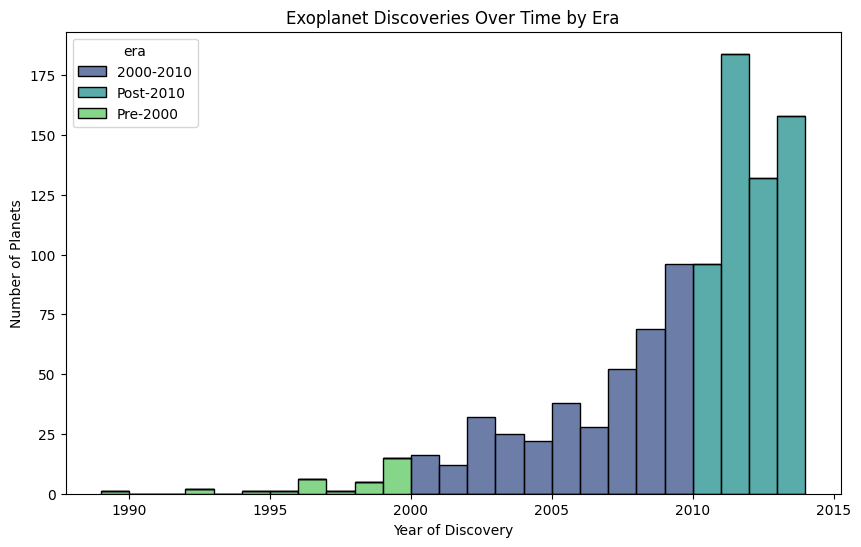

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.histplot(data=df, x='year', hue='era', multiple='stack', palette='viridis')

plt.title('Exoplanet Discoveries Over Time by Era')
plt.xlabel('Year of Discovery')
plt.ylabel('Number of Planets')
plt.show()

In [15]:
# Save the cleaned dataframe to a new CSV file
df.to_csv('cleaned_planets_data.csv', index=False)
print("Cleaned data saved as 'cleaned_planets_data.csv'!")

Cleaned data saved as 'cleaned_planets_data.csv'!


In [16]:
# Save the cleaned dataframe to your current folder
df.to_csv('cleaned_planets_data.csv', index=False)

print("File 'cleaned_planets_data.csv' has been created in your project folder.")

File 'cleaned_planets_data.csv' has been created in your project folder.


In [17]:
import os
print(os.getcwd())

C:\Users\Administrator
